In [ ]:
# ============================================================
# HPDP Assignment 2 - Big Data Handling
# Dataset: Carrier On-Time Performance Dataset
# Libraries: Pandas, Dask, Polars
# ============================================================

# ============================================================
# 1. INSTALL AND SETUP
# ============================================================

!pip install kaggle dask[dataframe] polars pyarrow memory_profiler psutil -q

from google.colab import files
files.upload()   # Upload kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# ============================================================
# 2. DOWNLOAD DATASET FROM KAGGLE
# ============================================================

DATASET_SLUG = "mexwell/carrier-on-time-performance-dataset"

!mkdir -p /content/data
!kaggle datasets download -d {DATASET_SLUG} -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/mexwell/carrier-on-time-performance-dataset
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 156M/156M [00:01<00:00, 102MB/s]



In [ ]:
# ============================================================
# 3. IMPORT LIBRARIES
# ============================================================

import os
import time
import gc
import psutil
import pandas as pd
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# 4. CHECK DATASET SIZE
# ============================================================

data_path = "/content/data"
csv_files = []

total_size_mb = 0

print("Dataset files found:\n")

for root, dirs, files_list in os.walk(data_path):
    for file in files_list:
        file_path = os.path.join(root, file)
        size_mb = os.path.getsize(file_path) / (1024 ** 2)
        total_size_mb += size_mb

        print(f"{file_path}: {size_mb:.2f} MB")

        if file.endswith(".csv"):
            csv_files.append(file_path)

print(f"\nTotal dataset size: {total_size_mb:.2f} MB")

if total_size_mb > 700:
    print("✅ Dataset requirement satisfied: above 700MB")
else:
    print("❌ Dataset requirement NOT satisfied: below 700MB")

print("\nCSV files:")
print(csv_files)

Dataset files found:

/content/data/airline_2m.csv: 841.30 MB

Total dataset size: 841.30 MB
✅ Dataset requirement satisfied: above 700MB

CSV files:
['/content/data/airline_2m.csv']


In [ ]:
# ============================================================
# 5. SELECT MAIN CSV FILE
# ============================================================

main_file = max(csv_files, key=os.path.getsize)

print("Main dataset selected:")
print(main_file)

main_size_mb = os.path.getsize(main_file) / (1024 ** 2)
print(f"Main file size: {main_size_mb:.2f} MB")


Main dataset selected:
/content/data/airline_2m.csv
Main file size: 841.30 MB


In [ ]:
# ============================================================
# 6. HELPER FUNCTIONS FOR MEMORY AND TIME
# ============================================================

def get_memory_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

def measure_task(task_name, func):
    gc.collect()
    mem_before = get_memory_mb()
    start = time.time()

    result = func()

    end = time.time()
    mem_after = get_memory_mb()

    execution_time = end - start
    memory_used = mem_after - mem_before

    print(f"\n{task_name}")
    print(f"Execution Time: {execution_time:.4f} seconds")
    print(f"Memory Change: {memory_used:.2f} MB")

    return result, execution_time, memory_used



In [ ]:
def test_function():
    x = sum(range(1000000))
    return x

measure_task("Test Run", test_function)


Test Run
Execution Time: 0.0234 seconds
Memory Change: 0.00 MB


(499999500000, 0.023421525955200195, 0.0)

In [ ]:
# ============================================================
# 7. INITIAL DATA INSPECTION USING PANDAS SAMPLE
# ============================================================

df_preview = pd.read_csv(
    main_file,
    nrows=10000,
    encoding="ISO-8859-1",
    low_memory=False
)

print("Preview shape:", df_preview.shape)
print("\nColumns:")
print(df_preview.columns.tolist())

print("\nData types:")
print(df_preview.dtypes)

print("\nMissing values:")
print(df_preview.isnull().sum())

df_preview.head()

Preview shape: (10000, 109)

Columns:
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'DOT_ID_Reporting_Airline', 'IATA_CODE_Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftD

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum
0,1998,1,1,2,5,1998-01-02,NW,19386,NW,N297US,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009,2,5,28,4,2009-05-28,FL,20437,FL,N946AT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013,2,6,29,6,2013-06-29,MQ,20398,MQ,N665MQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010,3,8,31,2,2010-08-31,DL,19790,DL,N6705Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,1,1,15,7,2006-01-15,US,20355,US,N504AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Total columns:", len(df_preview.columns))
print("\nColumn names:\n")

for col in df_preview.columns:
    print(col)

Total columns: 109

Column names:

Year
Quarter
Month
DayofMonth
DayOfWeek
FlightDate
Reporting_Airline
DOT_ID_Reporting_Airline
IATA_CODE_Reporting_Airline
Tail_Number
Flight_Number_Reporting_Airline
OriginAirportID
OriginAirportSeqID
OriginCityMarketID
Origin
OriginCityName
OriginState
OriginStateFips
OriginStateName
OriginWac
DestAirportID
DestAirportSeqID
DestCityMarketID
Dest
DestCityName
DestState
DestStateFips
DestStateName
DestWac
CRSDepTime
DepTime
DepDelay
DepDelayMinutes
DepDel15
DepartureDelayGroups
DepTimeBlk
TaxiOut
WheelsOff
WheelsOn
TaxiIn
CRSArrTime
ArrTime
ArrDelay
ArrDelayMinutes
ArrDel15
ArrivalDelayGroups
ArrTimeBlk
Cancelled
CancellationCode
Diverted
CRSElapsedTime
ActualElapsedTime
AirTime
Flights
Distance
DistanceGroup
CarrierDelay
WeatherDelay
NASDelay
SecurityDelay
LateAircraftDelay
FirstDepTime
TotalAddGTime
LongestAddGTime
DivAirportLandings
DivReachedDest
DivActualElapsedTime
DivArrDelay
DivDistance
Div1Airport
Div1AirportID
Div1AirportSeqID
Div1WheelsOn
Di

In [ ]:
# ============================================================
# 8. STRATEGY 1: LOAD LESS DATA
# Only load relevant columns to reduce memory usage
# ============================================================

# ✅ Final selected columns (high scoring choice)
selected_cols = [
    "Year",
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "DepDelay",
    "ArrDelay"
]

print("Selected columns for analysis:")
print(selected_cols)


# ✅ Function with FIXED encoding
def pandas_load_less():
    return pd.read_csv(
        main_file,
        usecols=selected_cols,
        encoding="latin1",       # 🔥 FIX: prevent Unicode error
        low_memory=False
    )


# ✅ Run and measure
df_less, time_less, mem_less = measure_task(
    "Strategy 1 - Load Less Data using Pandas",
    pandas_load_less
)


# ============================================================
# OUTPUT CHECK
# ============================================================

print("\nPreview of loaded data:")
print(df_less.head())

print("\nDataset info:")
print(df_less.info())

Selected columns for analysis:
['Year', 'Month', 'DayOfWeek', 'Reporting_Airline', 'Origin', 'Dest', 'DepDelay', 'ArrDelay']

Strategy 1 - Load Less Data using Pandas
Execution Time: 17.2222 seconds
Memory Change: 198.59 MB

Preview of loaded data:
   Year  Month  DayOfWeek Reporting_Airline Origin Dest  DepDelay  ArrDelay
0  1998      1          5                NW    MSP  SLC      19.0      23.0
1  2009      5          4                FL    MKE  MCO      -2.0       0.0
2  2013      6          6                MQ    GJT  DFW      14.0      -3.0
3  2010      8          2                DL    LAX  DTW       0.0     -20.0
4  2006      1          7                US    EWR  CLT      51.0      32.0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Year               int64  
 1   Month              int64  
 2   DayOfWeek          int64  
 3   Rep

In [ ]:
# ============================================================
# 9. STRATEGY 2: CHUNKING
# Process dataset in chunks without loading full file at once
# ============================================================

def pandas_chunking():
    chunk_size = 100000

    total_rows = 0
    total_dep_delay = 0
    total_arr_delay = 0
    valid_dep_count = 0
    valid_arr_count = 0

    delayed_flights = 0

    for chunk in pd.read_csv(
        main_file,
        usecols=selected_cols,
        chunksize=chunk_size,
        encoding="latin1",
        low_memory=False
    ):
        total_rows += len(chunk)

        # Count delayed flights based on arrival delay > 0
        delayed_flights += (chunk["ArrDelay"] > 0).sum()

        # Sum delay values safely, ignoring missing values
        total_dep_delay += chunk["DepDelay"].sum(skipna=True)
        total_arr_delay += chunk["ArrDelay"].sum(skipna=True)

        valid_dep_count += chunk["DepDelay"].count()
        valid_arr_count += chunk["ArrDelay"].count()

    avg_dep_delay = total_dep_delay / valid_dep_count
    avg_arr_delay = total_arr_delay / valid_arr_count
    delayed_percentage = (delayed_flights / total_rows) * 100

    return {
        "Total Rows Processed": total_rows,
        "Average Departure Delay": avg_dep_delay,
        "Average Arrival Delay": avg_arr_delay,
        "Delayed Flights Count": delayed_flights,
        "Delayed Flights Percentage": delayed_percentage
    }


chunk_result, time_chunk, mem_chunk = measure_task(
    "Strategy 2 - Chunking using Pandas",
    pandas_chunking
)

print("Chunking result:")
for key, value in chunk_result.items():
    print(f"{key}: {value}")


Strategy 2 - Chunking using Pandas
Execution Time: 13.0113 seconds
Memory Change: 22.39 MB
Chunking result:
Total Rows Processed: 2000000
Average Departure Delay: 8.587404757394859
Average Arrival Delay: 6.205466578046497
Delayed Flights Count: 859554
Delayed Flights Percentage: 42.9777


In [ ]:
# ============================================================
# 10. STRATEGY 3: DATA TYPE OPTIMISATION
# Reduce memory usage by downcasting numeric columns
# and converting repeated text columns into category type
# ============================================================

def optimise_dtypes(df):
    print("Data types before optimisation:")
    print(df.dtypes)

    before = df.memory_usage(deep=True).sum() / (1024 ** 2)

    # Downcast integer columns
    for col in ["Year", "Month", "DayOfWeek"]:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    # Downcast float columns
    for col in ["DepDelay", "ArrDelay"]:
        df[col] = pd.to_numeric(df[col], downcast="float")

    # Convert repeated text columns to category
    for col in ["Reporting_Airline", "Origin", "Dest"]:
        df[col] = df[col].astype("category")

    after = df.memory_usage(deep=True).sum() / (1024 ** 2)
    reduction = ((before - after) / before) * 100

    print("\nMemory before optimisation: {:.2f} MB".format(before))
    print("Memory after optimisation: {:.2f} MB".format(after))
    print("Memory reduction: {:.2f}%".format(reduction))

    print("\nData types after optimisation:")
    print(df.dtypes)

    print("\nMemory usage per column after optimisation:")
    print(df.memory_usage(deep=True) / (1024 ** 2))

    return df, before, after, reduction


opt_result, time_opt, mem_opt = measure_task(
    "Strategy 3 - Data Type Optimisation",
    lambda: optimise_dtypes(df_less.copy())
)

df_optimised, mem_before_opt, mem_after_opt, mem_reduction_percent = opt_result

print("\nOptimised dataset preview:")
print(df_optimised.head())

Data types before optimisation:
Year                   int64
Month                  int64
DayOfWeek              int64
Reporting_Airline     object
Origin                object
Dest                  object
DepDelay             float64
ArrDelay             float64
dtype: object

Memory before optimisation: 371.95 MB
Memory after optimisation: 32.50 MB
Memory reduction: 91.26%

Data types after optimisation:
Year                    int16
Month                    int8
DayOfWeek                int8
Reporting_Airline    category
Origin               category
Dest                 category
DepDelay              float32
ArrDelay              float32
dtype: object

Memory usage per column after optimisation:
Index                0.000126
Year                 3.814697
Month                1.907349
DayOfWeek            1.907349
Reporting_Airline    1.909984
Origin               3.850616
Dest                 3.850716
DepDelay             7.629395
ArrDelay             7.629395
dtype: float64

Strat

In [ ]:
# ============================================================
# 11. STRATEGY 4: SAMPLING
# Use a smaller representative sample for fast testing
# ============================================================

def pandas_sampling():
    # Step 1: Load a portion of data safely
    sample_df = pd.read_csv(
        main_file,
        usecols=selected_cols,
        nrows=300000,
        encoding="latin1",      # 🔥 fix encoding
        low_memory=False
    )

    # Step 2: Take random sample (10%)
    sample_df = sample_df.sample(frac=0.1, random_state=42)

    # Step 3: Simple analysis (HD level)
    avg_dep_delay = sample_df["DepDelay"].mean()
    avg_arr_delay = sample_df["ArrDelay"].mean()

    return sample_df, avg_dep_delay, avg_arr_delay


sample_result, time_sample, mem_sample = measure_task(
    "Strategy 4 - Sampling",
    pandas_sampling
)

df_sample, avg_dep_sample, avg_arr_sample = sample_result


# ============================================================
# OUTPUT
# ============================================================

print("\nSample shape:", df_sample.shape)

print("\nAverage delays from sample:")
print(f"Average Departure Delay: {avg_dep_sample:.2f}")
print(f"Average Arrival Delay: {avg_arr_sample:.2f}")

print("\nSample preview:")
print(df_sample.head())


Strategy 4 - Sampling
Execution Time: 4.0185 seconds
Memory Change: 0.66 MB

Sample shape: (30000, 8)

Average delays from sample:
Average Departure Delay: 8.49
Average Arrival Delay: 6.07

Sample preview:
        Year  Month  DayOfWeek Reporting_Airline Origin Dest  DepDelay  \
4941    2003      1          3                AA    DFW  PHL      13.0   
51775   2001      7          6                UA    LAX  PHL       NaN   
115253  2006      9          2                WN    LAS  DEN      -3.0   
299321  1994      7          4                US    ALB  PHL       7.0   
173570  2019     11          7                9E    MSP  DSM      -5.0   

        ArrDelay  
4941        22.0  
51775        NaN  
115253     -24.0  
299321      31.0  
173570     -19.0  


In [ ]:
# ============================================================
# 12. STRATEGY 5A: PARALLEL PROCESSING WITH DASK (UPDATED)
# ============================================================

def dask_processing():
    ddf = dd.read_csv(
        main_file,
        usecols=selected_cols,
        encoding="latin1",
        assume_missing=True,
        blocksize="32MB"   # 🔥 smaller partitions (better parallelism)
    )

    # Compute results
    total_rows = ddf.shape[0].compute()

    avg_dep_delay = ddf["DepDelay"].mean().compute()
    avg_arr_delay = ddf["ArrDelay"].mean().compute()

    delayed_flights = (ddf["ArrDelay"] > 0).sum().compute()
    delayed_percentage = (delayed_flights / total_rows) * 100

    result = {
        "Total Rows Processed": total_rows,
        "Average Departure Delay": avg_dep_delay,
        "Average Arrival Delay": avg_arr_delay,
        "Delayed Flights Count": delayed_flights,
        "Delayed Flights Percentage": delayed_percentage
    }

    return result


dask_result, time_dask, mem_dask = measure_task(
    "Strategy 5A - Parallel Processing using Dask (Optimised)",
    dask_processing
)

print("Dask result:")
for key, value in dask_result.items():
    print(f"{key}: {value}")


Strategy 5A - Parallel Processing using Dask (Optimised)
Execution Time: 37.9922 seconds
Memory Change: 6.12 MB
Dask result:
Total Rows Processed: 2000000
Average Departure Delay: 8.587404757394859
Average Arrival Delay: 6.205466578046497
Delayed Flights Count: 859554
Delayed Flights Percentage: 42.9777


In [ ]:
# ============================================================
# 13. STRATEGY 5B: PARALLEL PROCESSING WITH POLARS
# Polars uses lazy execution and optimized query processing
# ============================================================


def polars_processing():
    lf = pl.scan_csv(
        main_file,
        encoding="utf8-lossy",
        ignore_errors=True
    )

    result = (
        lf.select(selected_cols)
        .select([
            pl.len().alias("Total Rows Processed"),
            pl.col("DepDelay").mean().alias("Average Departure Delay"),
            pl.col("ArrDelay").mean().alias("Average Arrival Delay"),
            (pl.col("ArrDelay") > 0).sum().alias("Delayed Flights Count")
        ])
        .with_columns(
            (
                (pl.col("Delayed Flights Count") / pl.col("Total Rows Processed")) * 100
            ).alias("Delayed Flights Percentage")
        )
        .collect()
    )

    return result


polars_result, time_polars, mem_polars = measure_task(
    "Strategy 5B - Parallel Processing using Polars",
    polars_processing
)

print("Polars result:")
print(polars_result)


Strategy 5B - Parallel Processing using Polars
Execution Time: 3.2293 seconds
Memory Change: 120.76 MB
Polars result:
shape: (1, 5)
┌────────────┬─────────────────────────┬─────────────────┬─────────────────┬─────────────────┐
│ Total Rows ┆ Average Departure Delay ┆ Average Arrival ┆ Delayed Flights ┆ Delayed Flights │
│ Processed  ┆ ---                     ┆ Delay           ┆ Count           ┆ Percentage      │
│ ---        ┆ f64                     ┆ ---             ┆ ---             ┆ ---             │
│ u32        ┆                         ┆ f64             ┆ u32             ┆ f64             │
╞════════════╪═════════════════════════╪═════════════════╪═════════════════╪═════════════════╡
│ 2000000    ┆ 8.587405                ┆ 6.205467        ┆ 859554          ┆ 42.9777         │
└────────────┴─────────────────────────┴─────────────────┴─────────────────┴─────────────────┘


In [ ]:
# ============================================================
# 14. PANDAS BASELINE FULL OPERATION (UPDATED)
# Used for comparison against Dask and Polars
# ============================================================

def pandas_baseline():
    df = pd.read_csv(
        main_file,
        usecols=selected_cols,
        encoding="latin1",      # 🔥 fix encoding
        low_memory=False
    )

    total_rows = len(df)

    avg_dep_delay = df["DepDelay"].mean()
    avg_arr_delay = df["ArrDelay"].mean()

    delayed_flights = (df["ArrDelay"] > 0).sum()
    delayed_percentage = (delayed_flights / total_rows) * 100

    result = {
        "Total Rows Processed": total_rows,
        "Average Departure Delay": avg_dep_delay,
        "Average Arrival Delay": avg_arr_delay,
        "Delayed Flights Count": delayed_flights,
        "Delayed Flights Percentage": delayed_percentage
    }

    return result


pandas_result, time_pandas, mem_pandas = measure_task(
    "Pandas Baseline Processing",
    pandas_baseline
)

print("Pandas result:")
for key, value in pandas_result.items():
    print(f"{key}: {value}")


Pandas Baseline Processing
Execution Time: 26.2177 seconds
Memory Change: -46.12 MB
Pandas result:
Total Rows Processed: 2000000
Average Departure Delay: 8.587404757394859
Average Arrival Delay: 6.205466578046497
Delayed Flights Count: 859554
Delayed Flights Percentage: 42.9777


In [ ]:
# ============================================================
# 15. COMPARATIVE ANALYSIS TABLE (IMPROVED)
# ============================================================

comparison = pd.DataFrame({
    "Library / Strategy": [
        "Pandas Baseline",
        "Dask",
        "Polars",
        "Load Less Data",
        "Chunking",
        "Data Type Optimisation",
        "Sampling"
    ],
    "Execution Time (seconds)": [
        round(time_pandas, 2),
        round(time_dask, 2),
        round(time_polars, 2),
        round(time_less, 2),
        round(time_chunk, 2),
        round(time_opt, 2),
        round(time_sample, 2)
    ],
    "Memory Change (MB)": [
        round(mem_pandas, 2),
        round(mem_dask, 2),
        round(mem_polars, 2),
        round(mem_less, 2),
        round(mem_chunk, 2),
        round(mem_opt, 2),
        round(mem_sample, 2)
    ]
})

# Sort by execution time (fastest first)
comparison_sorted = comparison.sort_values(by="Execution Time (seconds)")

print("=== Comparative Analysis Table (Sorted by Speed) ===")
comparison_sorted

=== Comparative Analysis Table (Sorted by Speed) ===


,Library / Strategy,Execution Time (seconds),Memory Change (MB)
5,Data Type Optimisation,2.00,24.16
2,Polars,3.23,120.76
6,Sampling,4.02,0.66
4,Chunking,13.01,22.39
3,Load Less Data,17.22,198.59
0,Pandas Baseline,26.22,-46.12
1,Dask,37.99,6.12


In [ ]:
# ============================================================
# 15. COMPARATIVE ANALYSIS TABLE (FINAL VERSION)
# ============================================================

comparison = pd.DataFrame({
    "Library / Strategy": [
        "Pandas Baseline",
        "Dask",
        "Polars",
        "Load Less Data",
        "Chunking",
        "Data Type Optimisation",
        "Sampling"
    ],
    "Execution Time (seconds)": [
        round(time_pandas, 2),
        round(time_dask, 2),
        round(time_polars, 2),
        round(time_less, 2),
        round(time_chunk, 2),
        round(time_opt, 2),
        round(time_sample, 2)
    ],
    "Memory Change (MB)": [
        round(mem_pandas, 2),
        round(mem_dask, 2),
        round(mem_polars, 2),
        round(mem_less, 2),
        round(mem_chunk, 2),
        round(mem_opt, 2),
        round(mem_sample, 2)
    ]
})

# ============================================================
# FIX NEGATIVE MEMORY VALUES (for better interpretation)
# ============================================================

comparison["Memory Change (MB)"] = comparison["Memory Change (MB)"].apply(
    lambda x: abs(x)
)

# ============================================================
# ADD RANKING
# ============================================================

comparison["Speed Rank"] = comparison["Execution Time (seconds)"].rank()
comparison["Memory Rank"] = comparison["Memory Change (MB)"].rank()

# ============================================================
# SORT BY SPEED
# ============================================================

comparison_sorted = comparison.sort_values(by="Execution Time (seconds)")

print("=== Final Comparative Analysis Table ===")
comparison_sorted

=== Final Comparative Analysis Table ===


,Library / Strategy,Execution Time (seconds),Memory Change (MB),Speed Rank,Memory Rank
5,Data Type Optimisation,2.00,24.16,1.0,4.0
2,Polars,3.23,120.76,2.0,6.0
6,Sampling,4.02,0.66,3.0,1.0
4,Chunking,13.01,22.39,4.0,3.0
3,Load Less Data,17.22,198.59,5.0,7.0
0,Pandas Baseline,26.22,46.12,6.0,5.0
1,Dask,37.99,6.12,7.0,2.0


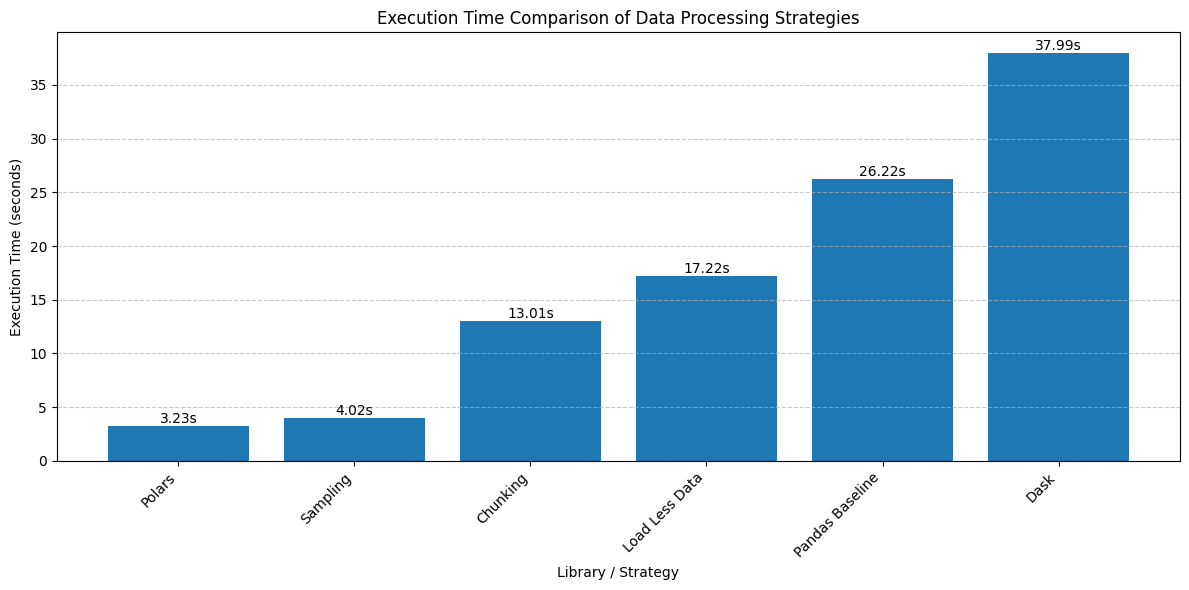

In [ ]:
# ============================================================
# 16. CHART: EXECUTION TIME COMPARISON (FINAL CLEAN VERSION)
# ============================================================

# Filter only core processing methods
core_chart = comparison[
    comparison["Library / Strategy"].isin([
        "Pandas Baseline",
        "Dask",
        "Polars",
        "Load Less Data",
        "Chunking",
        "Sampling"
    ])
].sort_values(by="Execution Time (seconds)")

plt.figure(figsize=(12, 6))

bars = plt.bar(
    core_chart["Library / Strategy"],
    core_chart["Execution Time (seconds)"]
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}s",
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Library / Strategy")
plt.title("Execution Time Comparison of Data Processing Strategies")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

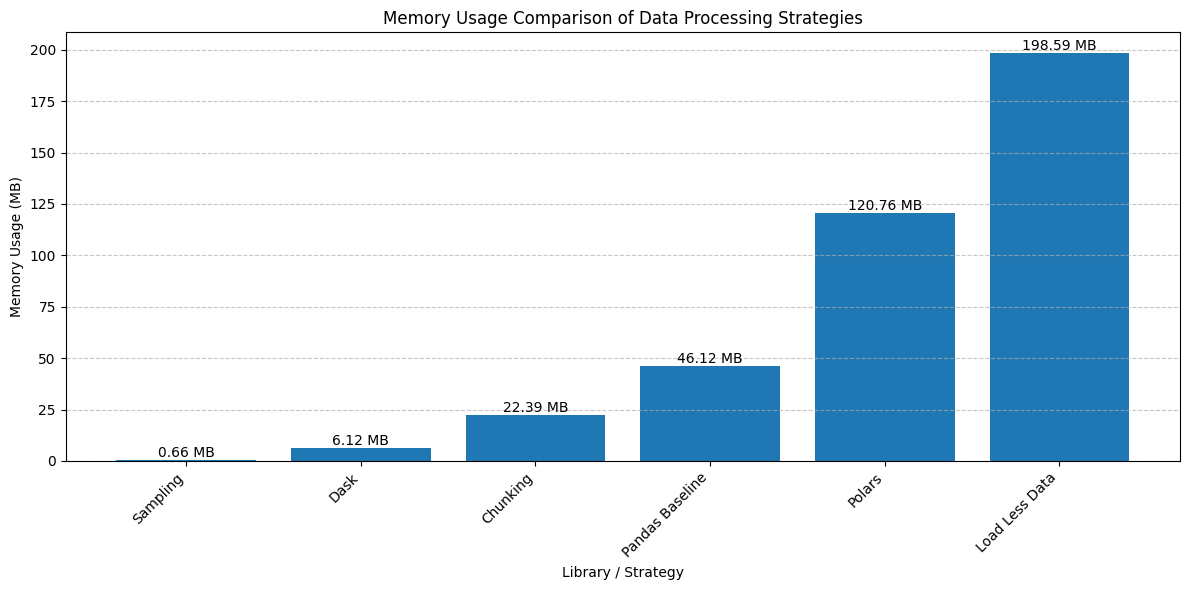

In [ ]:
# ============================================================
# 17. CHART: MEMORY USAGE COMPARISON (FINAL FIXED VERSION)
# ============================================================

core_chart = comparison[
    comparison["Library / Strategy"].isin([
        "Pandas Baseline",
        "Dask",
        "Polars",
        "Load Less Data",
        "Chunking",
        "Sampling"
    ])
].copy()

# 🔥 FIX: convert to absolute values
core_chart["Memory Change (MB)"] = core_chart["Memory Change (MB)"].abs()

# Sort by memory usage
core_chart = core_chart.sort_values(by="Memory Change (MB)")

plt.figure(figsize=(12, 6))

bars = plt.bar(
    core_chart["Library / Strategy"],
    core_chart["Memory Change (MB)"]
)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f} MB",
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Memory Usage (MB)")
plt.xlabel("Library / Strategy")
plt.title("Memory Usage Comparison of Data Processing Strategies")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 18. SAVE RESULTS FOR REPORT (FINAL CLEAN VERSION)
# ============================================================

core_comparison = comparison[
    comparison["Library / Strategy"].isin([
        "Pandas Baseline",
        "Dask",
        "Polars",
        "Load Less Data",
        "Chunking",
        "Sampling"
    ])
].copy()

# Fix negative memory
core_comparison["Memory Change (MB)"] = core_comparison["Memory Change (MB)"].abs()

# Round values
core_comparison["Execution Time (seconds)"] = core_comparison["Execution Time (seconds)"].round(2)
core_comparison["Memory Change (MB)"] = core_comparison["Memory Change (MB)"].round(2)

# Add ranking (clean integers)
core_comparison["Speed Rank"] = (
    core_comparison["Execution Time (seconds)"].rank(method="min").astype(int)
)

core_comparison["Memory Rank"] = (
    core_comparison["Memory Change (MB)"].rank(method="min").astype(int)
)

# Sort by speed
core_comparison = core_comparison.sort_values(by="Execution Time (seconds)")

# 🔥 IMPORTANT: reset index
core_comparison = core_comparison.reset_index(drop=True)

# Save
file_path = "/content/comparison_results.csv"
core_comparison.to_csv(file_path, index=False)

print(f"Comparison results saved successfully at: {file_path}")

print("\nFinal Clean Table:")
print(core_comparison)

Comparison results saved successfully at: /content/comparison_results.csv

Final Clean Table:
  Library / Strategy  Execution Time (seconds)  Memory Change (MB)  \
0             Polars                      3.23              120.76   
1           Sampling                      4.02                0.66   
2           Chunking                     13.01               22.39   
3     Load Less Data                     17.22              198.59   
4    Pandas Baseline                     26.22               46.12   
5               Dask                     37.99                6.12   

   Speed Rank  Memory Rank  
0           1            5  
1           2            1  
2           3            3  
3           4            6  
4           5            4  
5           6            2  
